<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>Image Compression and Generation using Variational Autoencoders in Python</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">PyTorch Implementation &bull; Character Font Synthesis &bull; Deep Generative Modeling</span>
</div>

---

# Table of Contents 

- [Prerequisites](#prerequisites)
1. [Task 1: Introduction & Theoretical Background](#task-1-introduction)
   - 1.1 [Autoencoder (AE) vs. Variational Autoencoder (VAE)](#11-autoencoder-vs-vae)
   - 1.2 [The Reparameterization Trick](#12-reparameterization-trick)
   - 1.3 [The Loss Function (ELBO: BCE + KLD)](#13-loss-function-elbo)
   - 1.4 [Image Compression and Generative Synthesis](#14-compression-and-generation)
2. [Task 2: Exploratory Data Analysis and Preprocessing](#task-2-exploratory-data-analysis-and-preprocessing)
3. [Task 3: Training/Validation Split](#task-3-training-validation-split)
4. [Task 4: Creating Data Loaders](#task-4-creating-data-loaders)
5. [Task 5: VAE Architecture and Model Creation](#task-5-vae-architecture-and-model-creation)
6. [Task 6: Training Loop & Model Optimization](#task-6-training-loop)
   - 6.1 [Validation Evaluation & Latent Sampling Functions](#61-evaluation)
   - 6.2 [Single Epoch Training Step](#62-training-epoch)
   - 6.3 [Execute Model Training](#63-training-execution)
7. [Task 7: Results, Visualizations, and Latent Exploration](#task-7-results-and-other-uses)
   - 7.1 [Loading Model Weights & Checkpoints](#71-loading-weights)
   - 7.2 [Training & Validation Loss Analysis](#72-loss-analysis)
   - 7.3 [Generating New Characters from Random Latent Noise](#73-generating-characters)
   - 7.4 [Latent Space Interpolation (Morphing)](#74-latent-interpolation)
   - 7.5 [Validation Set Reconstruction: Input vs. VAE Output](#75-reconstructions)

---


<a id="prerequisites"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">Prerequisites</span>

- Intermediate-level knowledge of Python 3 (working with arrays, vectors, and image processing)
- Exposure to PyTorch fundamentals (tensors, modules, datasets, and training loops)
- Basic understanding of Autoencoders and Generative Models

<a id="task-1-introduction"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 1: Introduction & Theoretical Background</span>

<div align="center"> 
  <img src="assets/vae.png" width="750" alt="Variational Autoencoder Architecture" style="border-radius: 10px;"> 
</div>

<a id="11-autoencoder-vs-vae"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">1.1 Autoencoder (AE) vs. Variational Autoencoder (VAE)</span>

A standard **Autoencoder** consists of two components:
1. **Encoder ($q_\phi$)**: Compresses high-dimensional input $x$ into a single bottleneck vector $z$ in latent space.
2. **Decoder ($p_\theta$)**: Reconstructs the original image $\hat{x}$ from the latent code $z$.

### Why can't a standard Autoencoder generate new data?
Standard autoencoders learn deterministic mappings to discrete points in latent space. Because there is no constraint on how these points are arranged, the latent space ends up with large "holes" or gaps between clusters. If you pick a random point $z$ from an empty region and feed it to the decoder, the output is meaningless noise.

### The Variational Autoencoder Solution:
A **Variational Autoencoder (VAE)** is a probabilistic generative model:
- Instead of outputting a single point $z$, the encoder outputs the parameters of a probability distribution:
  - **Mean vector ($\mu$)**: The center of the distribution.
  - **Log-variance vector ($\log \sigma^2$)**: The spread/uncertainty around the mean.
- A latent vector $z$ is then sampled from this Gaussian distribution: $z \sim \mathcal{N}(\mu, \sigma^2 I)$.
- This probabilistic formulation ensures the latent space is **continuous, complete, and smooth**: nearby points decode into visually similar, realistic outputs.

<a id="12-reparameterization-trick"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">1.2 The Reparameterization Trick</span>

### The Backpropagation Challenge:
In a neural network, gradients flow backward through every operation. However, random sampling $z \sim \mathcal{N}(\mu, \sigma^2)$ is a stochastic operation—there is no defined derivative with respect to $\mu$ or $\sigma$. Backpropagation would be blocked at the sampling step.

### The Solution:
The **Reparameterization Trick** isolates the randomness into an independent auxiliary noise vector $\epsilon \sim \mathcal{N}(0, I)$:

$$z = \mu + \sigma \odot \epsilon = \mu + \exp\left(\frac{1}{2} \log \sigma^2\right) \odot \epsilon$$

Where:
- $\odot$ denotes element-wise multiplication.
- $\mu$ and $\log \sigma^2$ are deterministic outputs of the encoder network.
- $\epsilon$ is fixed random noise from a standard normal distribution.

Because $z$ is now expressed as a deterministic, continuous linear transformation of $\mu$ and $\sigma$, gradients can flow freely from the loss function backward to the encoder!

<a id="13-loss-function-elbo"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">1.3 The Loss Function (ELBO: BCE + KLD)</span>

The objective function of a VAE maximizes the **Evidence Lower Bound (ELBO)**, which is framed as minimizing two loss terms:

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{Reconstruction}} + \mathcal{L}_{\text{KL Divergence}}$$

### 1. Reconstruction Loss (Binary Cross-Entropy):
Measures how accurately the reconstructed pixels $\hat{x}$ match the original pixels $x$:

$$\text{BCE}(x, \hat{x}) = -\sum_{i=1}^{D} \left[ x_i \log \hat{x}_i + (1 - x_i) \log(1 - \hat{x}_i) \right]$$

### 2. Kullback-Leibler (KL) Divergence:
Measures how closely the learned latent distribution $q_\phi(z|x) = \mathcal{N}(\mu, \sigma^2)$ matches a standard normal prior $p(z) = \mathcal{N}(0, I)$:

$$D_{KL}\left(\mathcal{N}(\mu, \sigma^2) \parallel \mathcal{N}(0, I)\right) = -\frac{1}{2} \sum_{j=1}^{d} \left( 1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2 \right)$$

### The Regularization Tug-of-War:
- **Reconstruction Loss** wants each image to have its own unique, separated latent region so it can reconstruct fine visual details.
- **KL Divergence** pulls all latent distributions toward the center $\mathcal{N}(0, I)$, preventing clusters from scattering and filling empty spaces.
- Together, they produce a smooth, continuous latent space perfectly suited for interpolation and generation.

<a id="14-compression-and-generation"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">1.4 Image Compression and Generative Synthesis</span>

### Image Compression:
- An uncompressed grayscale image of size $50 \times 50$ has **2,500 pixel values**.
- The VAE encoder compresses this image into a latent vector of just **$z = 32$ dimensions**.
- This achieves a compression ratio of:

$$\text{Compression Ratio} = \frac{2500}{32} \approx 78.1 \times \quad (98.7\% \text{ reduction in data!})$$

### Generative Synthesis:
- To generate an entirely brand-new font character that was never in the training set:
  1. Sample a random 32-dimensional vector: $z \sim \mathcal{N}(0, I)$.
  2. Pass $z$ through the decoder network: $\hat{x} = \text{Decoder}(z)$.
  3. Reshape the 2,500 output values into a $50 \times 50$ image.

### Additional References & Resources
- [Resource 1: Blog Post by Jeremy Jordan](https://www.jeremyjordan.me/variational-autoencoders/)
- [Resource 2: Stanford CS228 Theory Post](https://ermongroup.github.io/cs228-notes/inference/variational/)
- [Resource 3: Video Lecture by Arxiv Insights](https://www.youtube.com/watch?v=P78QYjWh5sM&feature=youtu.be)
- [Official PyTorch VAE Example Repository](https://github.com/pytorch/examples/tree/master/vae)

In [1]:
# Standard library imports
import os
import shutil
import random

# Core PyTorch imports
import torch
import torch.utils.data
from torch import nn, optim
from torch.nn import functional as F
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid

# Progress bar for training
from tqdm.notebook import tqdm

# Numerical and plotting libraries
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Matplotlib configuration for crisp rendering
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
plt.style.use('ggplot')

# Global random seed configuration for reproducibility
RANDOM_SEED = 17
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Libraries imported and random seeds initialized successfully.")

Libraries imported and random seeds initialized successfully.


In [3]:
# Hyperparameter and environment configuration
epochs = 1000          # Total training epochs for full model convergence
batch_size = 64        # Batch size for data loaders
image_size = 50        # Image dimensions: 50x50 pixels
input_dim = 50 * 50    # Flattened image vector dimension (2500)
latent_dim = 32        # Bottleneck latent space dimension
learning_rate = 1e-3   # Optimizer learning rate

# Device selection: Use CUDA GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Execution Device: {device}')
print(f'Input Dimension : {input_dim} (50x50 pixels)')
print(f'Latent Dimension: {latent_dim}')

Execution Device: cpu
Input Dimension : 2500 (50x50 pixels)
Latent Dimension: 32


<a id="task-2-exploratory-data-analysis-and-preprocessing"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 2: Exploratory Data Analysis and Preprocessing</span>

We use computer-generated fonts from the [Character Font Images Data Set](http://archive.ics.uci.edu/ml/datasets/Character+Font+Images#).
Each character image is resized to a standardized dimension of $50 \times 50$ pixels and converted to single-channel grayscale.

In [4]:
def show_img(img, title=None):
    """
    Helper function to display a PyTorch image tensor or numpy array.
    Automatically handles channel squeezing and dimension ordering.
    """
    if isinstance(img, torch.Tensor):
        img = img.detach().cpu()
        if img.dim() == 3 and img.shape[0] == 1:
            img = img.squeeze(0)
        elif img.dim() == 3:
            img = img.permute(1, 2, 0)
        img = img.numpy()
        
    plt.figure(figsize=(3, 3))
    plt.imshow(img, cmap='gray')
    plt.title(title if title else f'Shape: {tuple(img.shape)}', fontsize=10)
    plt.axis('off')
    plt.show()

In [5]:
# Preprocessing transform pipeline: Grayscale conversion -> Resize to 50x50 -> ToTensor [0, 1]
import zipfile

transforms_all = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(size=image_size),
    transforms.ToTensor(),
])

# Ensure dataset is unpacked: check Font/all or extract Font.zip if present
if not os.path.exists('Font/all') and os.path.exists('Font.zip'):
    print("Extracting 'Font.zip' into 'Font/all'...")
    with zipfile.ZipFile('Font.zip', 'r') as z:
        members = [m for m in z.infolist() if not m.filename.startswith('__MACOSX') and not '.DS_Store' in m.filename]
        z.extractall(members=members)
    print("Extraction complete.")

# Dummy data loader to inspect raw dataset samples if available
if os.path.exists('Font/all/'):
    dummy_batch = torch.utils.data.DataLoader(
        datasets.ImageFolder('Font/all/', transform=transforms.ToTensor()),
        batch_size=1,
        shuffle=True
    )
    num_classes = len([d for d in os.listdir('Font/all/') if not d.startswith('.')])
    print(f"Dataset directory found with {num_classes} font classes: dummy loader created.")
else:
    dummy_batch = None
    print("Dataset note: 'Font/all/' directory not found locally.")
    print("Download instructions are provided in HOW_TO_FONTS.txt.")


Dataset directory found with 62 font classes: dummy loader created.


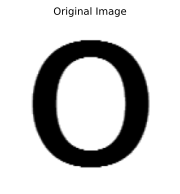

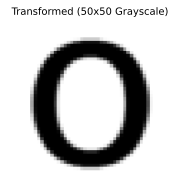

In [6]:
# Display an original image alongside its preprocessed (resized & grayscaled) version
if dummy_batch is not None:
    for batch in dummy_batch:
        original_image = batch[0][0]
        show_img(original_image, title="Original Image")
        transformed = transforms_all(transforms.ToPILImage()(original_image))
        show_img(transformed, title="Transformed (50x50 Grayscale)")
        break

<a id="task-3-training-validation-split"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 3: Training/Validation Split</span>

To evaluate model generalization accurately, we split the font character images:
- **Validation set**: First 20 random images from each font class (`Font/val/`)
- **Training set**: Remaining images from each font class (`Font/train/`)

In [7]:
# Organize files into train and validation sets
if os.path.exists('Font/all'):
    folders = [f for f in os.listdir('Font/all') if not f.startswith('.')]
    os.makedirs('Font/train', exist_ok=True)
    os.makedirs('Font/val', exist_ok=True)

    train_classes = [f for f in os.listdir('Font/train') if not f.startswith('.')]
    val_classes = [f for f in os.listdir('Font/val') if not f.startswith('.')]

    if len(train_classes) == len(folders) and len(val_classes) == len(folders):
        print(f"Dataset already split: 'Font/train' ({len(train_classes)} classes) and 'Font/val' ({len(val_classes)} classes) are ready.")
    else:
        for folder in tqdm(folders, desc="Splitting Classes"):
            os.makedirs(f'Font/val/{folder}', exist_ok=True)
            os.makedirs(f'Font/train/{folder}', exist_ok=True)
            
            images = [img for img in os.listdir(f'Font/all/{folder}') if not img.startswith('.')]
            random.shuffle(images)
            
            # 20 images to validation, rest to training
            for image in images[:20]:
                dest = f'Font/val/{folder}/{image}'
                if not os.path.exists(dest):
                    shutil.copy(f'Font/all/{folder}/{image}', dest)
                
            for image in images[20:]:
                dest = f'Font/train/{folder}/{image}'
                if not os.path.exists(dest):
                    shutil.copy(f'Font/all/{folder}/{image}', dest)
                
        print("Dataset split complete: 'Font/train' and 'Font/val' prepared.")
else:
    print("Dataset note: 'Font/all' directory not present locally.")
    print("Pre-saved models and outputs in 'Presaved_Models/' and 'Presaved_Results/' will be used.")


Dataset already split: 'Font/train' (62 classes) and 'Font/val' (62 classes) are ready.


<a id="task-4-creating-data-loaders"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 4: Creating Data Loaders</span>

In [8]:
transforms_set = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(size=image_size),
    transforms.ToTensor(),
])

if os.path.exists('Font/train') and os.path.exists('Font/val'):
    train_dataset = datasets.ImageFolder('Font/train', transform=transforms_set)
    val_dataset = datasets.ImageFolder('Font/val', transform=transforms_set)

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size, 
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=batch_size, 
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    print(f"Data loaders created successfully:")
    print(f"  - Training samples  : {len(train_dataset):,} across {len(train_loader)} batches")
    print(f"  - Validation samples: {len(val_dataset):,} across {len(val_loader)} batches")
else:
    train_loader = None
    val_loader = None
    print("Data loaders initialized to None (using pre-saved models and evaluations).")


Data loaders created successfully:
  - Training samples  : 61,752 across 965 batches
  - Validation samples: 1,240 across 20 batches


<a id="task-5-vae-architecture-and-model-creation"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 5: VAE Architecture and Model Creation</span>

### Neural Network Specifications:
- **Input layer**: $50 \times 50 = 2500$ flattened pixel values.
- **Encoder hidden layer**: Fully connected layer ($2500 \to 1000$) with ReLU activation.
- **Bottleneck heads**:
  - `fc21`: Linear projection to mean vector $\mu$ (32 dimensions).
  - `fc22`: Linear projection to log-variance vector $\log \sigma^2$ (32 dimensions).
- **Decoder hidden layer**: Fully connected layer ($32 \to 1000$) with ReLU activation.
- **Output layer**: Fully connected layer ($1000 \to 2500$) with Sigmoid activation to produce normalized pixel intensities in $[0, 1]$.

In [9]:
class VAE(nn.Module):
    def __init__(self, input_dim=2500, hidden_dim=1000, latent_dim=32):
        super(VAE, self).__init__()
        
        # Encoder network layers
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc21 = nn.Linear(hidden_dim, latent_dim)  # Computes mean vector (mu)
        self.fc22 = nn.Linear(hidden_dim, latent_dim)  # Computes log-variance vector (logvar)
        
        # Decoder network layers
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        """Encodes flattened image into mean and log-variance vectors."""
        h1 = F.relu(self.fc1(x))
        mu = self.fc21(h1)
        logvar = self.fc22(h1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick:
        z = mu + std * epsilon, where epsilon ~ N(0, I)
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        """Decodes latent vector z back into reconstructed pixel probabilities [0, 1]."""
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        """Full forward pass: Encode -> Reparameterize -> Decode."""
        # Flatten input from (batch_size, 1, 50, 50) to (batch_size, 2500)
        mu, logvar = self.encode(x.view(-1, 50 * 50))
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

In [10]:
def loss_function(recon_x, x, mu, logvar):
    """
    VAE Loss = Reconstruction Loss (BCE) + Latent Regularization (KLD)
    
    1. Binary Cross-Entropy (BCE):
       Measures reconstruction quality comparing predicted pixels with input pixels.
    2. Kullback-Leibler Divergence (KLD):
       Measures how much the latent distribution deviates from standard normal N(0, I).
    """
    # Binary Cross-Entropy summed over all pixels in batch
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 50 * 50), reduction='sum')

    # Closed-form KL Divergence for Gaussian distribution
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD

In [11]:
# Initialize VAE model and transfer to target device
model = VAE().to(device)

# Initialize Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print("VAE Model Architecture:")
print(model)

VAE Model Architecture:
VAE(
  (fc1): Linear(in_features=2500, out_features=1000, bias=True)
  (fc21): Linear(in_features=1000, out_features=32, bias=True)
  (fc22): Linear(in_features=1000, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1000, bias=True)
  (fc4): Linear(in_features=1000, out_features=2500, bias=True)
)


<a id="task-6-training-loop"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 6: Training Loop</span>

During each training epoch:
1. Pass input batch $x$ through the VAE to obtain reconstruction $\hat{x}$, mean $\mu$, and log-variance $\log \sigma^2$.
2. Calculate total loss $\mathcal{L} = \text{BCE} + \text{KLD}$.
3. Backpropagate gradients using `loss.backward()` and update weights using `optimizer.step()`.
4. Periodically evaluate validation loss and sample from the latent space to inspect progress.

<a id="61-evaluation"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.1 Validation Loss & Reconstruction Evaluation</span>


In [12]:
def evaluate(epoch=0, evaluate_data=None):
    """
    Evaluates model performance on validation data without gradient computation.
    Saves visual reconstruction comparisons for the first validation batch.
    """
    if evaluate_data is None:
        evaluate_data = val_loader
    if evaluate_data is None:
        return 0.0
        
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for i, (data, _) in enumerate(evaluate_data):
            data = data.to(device)
            recon_batch, mu, logvar = model(data)
            val_loss += loss_function(recon_batch, data, mu, logvar).item()
            
            # Save periodic visual comparison on first batch
            if i == 0:
                os.makedirs('Results', exist_ok=True)
                n = min(data.size(0), 16)
                comparison = torch.cat([data[:n], recon_batch.view(-1, 1, image_size, image_size)[:n]])
                save_image(comparison.cpu(), f'Results/reconstruction_{epoch}.png', nrow=n)

    val_loss /= len(evaluate_data.dataset)
    return val_loss


def sample_latent_space(epoch=0):
    """
    Samples 64 random latent vectors z ~ N(0, I) and saves decoded synthetic images.
    """
    with torch.no_grad():
        os.makedirs('Results', exist_ok=True)
        sample = torch.randn(64, latent_dim).to(device)
        sample = model.decode(sample).cpu()
        save_image(sample.view(64, 1, image_size, image_size), f'Results/sample_{epoch}.png')


<a id="62-training-epoch"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.2 Single Epoch Training Step</span>


In [13]:
def train(epoch):
    """
    Executes one full training epoch over the training dataset.
    Computes reconstruction + KL divergence losses, backpropagates gradients,
    records loss histories, and periodically saves checkpoints and latent samples.
    """
    global train_losses, val_losses
    if train_loader is None:
        print("Train loader not available. Please prepare the dataset in Tasks 2, 3, and 4.")
        return
        
    model.train()
    train_loss = 0.0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch:03d}', leave=False)
    for data, _ in progress_bar:
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

        progress_bar.set_postfix({'batch_loss': f'{loss.item() / len(data):.3f}'})

    average_train_loss = train_loss / len(train_loader.dataset)
    val_loss = evaluate(epoch=epoch, evaluate_data=val_loader)
    
    tqdm.write(f'Epoch {epoch:03d} -> Train Loss: {average_train_loss:.3f} | Val Loss: {val_loss:.3f}')

    train_losses.append(average_train_loss)
    val_losses.append(val_loss)
    
    # Periodically sample latent space
    if epoch % 10 == 0 or epoch == 1:
        sample_latent_space(epoch)
    
    # Save checkpoint every 25 epochs
    if epoch % 25 == 0:
        os.makedirs('Models', exist_ok=True)
        torch.save(model.state_dict(), f'Models/epoch_{epoch}.model')
        np.savetxt('Models/training_losses.txt', np.array(train_losses))
        np.savetxt('Models/validation_losses.txt', np.array(val_losses))


<a id="63-training-execution"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.3 Execute Model Training</span>


In [14]:
# ==============================================================================
# 6.3 Execute Training Loop
# ==============================================================================
# Configure number of training epochs:
# Default: 10 epochs (sufficient to verify learning & produce clear characters)
# Increase to 50-100+ for higher reconstruction fidelity
NUM_EPOCHS = 10

# Initialize loss tracking lists
if 'train_losses' not in globals() or not isinstance(train_losses, list):
    train_losses = []
if 'val_losses' not in globals() or not isinstance(val_losses, list):
    val_losses = []

if train_loader is not None and len(train_loader) > 0:
    print(f"Starting VAE training on device: '{device}'")
    print(f"Epochs to train: {NUM_EPOCHS}")
    print(f"Batches per epoch: {len(train_loader)} (batch size: {batch_size})")
    print("=" * 65)

    start_epoch = len(train_losses) + 1
    end_epoch = start_epoch + NUM_EPOCHS - 1

    for epoch in range(start_epoch, end_epoch + 1):
        train(epoch)

    # Save latest model checkpoint and loss curves
    os.makedirs('Models', exist_ok=True)
    latest_ckpt = 'Models/vae_latest.model'
    torch.save(model.state_dict(), latest_ckpt)
    torch.save(model.state_dict(), f'Models/epoch_{end_epoch}.model')
    np.savetxt('Models/training_losses.txt', np.array(train_losses))
    np.savetxt('Models/validation_losses.txt', np.array(val_losses))

    print("=" * 65)
    print(f"Training session complete! Total epochs trained: {len(train_losses)}")
    print(f"Latest checkpoint saved to: '{latest_ckpt}'")
    print(f"Loss curves saved to: 'Models/training_losses.txt' & 'Models/validation_losses.txt'")
    print(f"Reconstructions and sampled characters saved in 'Results/'")
else:
    print("Cannot start training: 'train_loader' is not initialized.")
    print("Please run Tasks 2, 3, and 4 to prepare the Character Font dataset.")


Starting VAE training on device: 'cpu'
Epochs to train: 10
Batches per epoch: 965 (batch size: 64)


Epoch 001:   0%|          | 0/965 [00:00<?, ?it/s]

Epoch 001 -> Train Loss: 407.997 | Val Loss: 324.559


Epoch 002:   0%|          | 0/965 [00:00<?, ?it/s]

Epoch 002 -> Train Loss: 304.028 | Val Loss: 299.180


Epoch 003:   0%|          | 0/965 [00:00<?, ?it/s]

KeyboardInterrupt: 

<a id="task-7-results-and-other-uses"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 7: Results, Visualizations, and Latent Exploration</span>

<a id="71-loading-weights"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">7.1 Loading Model Weights & Checkpoints</span>


In [15]:
# Load model weights: checks pre-trained weights first, then latest trained weights in Models/
checkpoint_candidates = [
    'Presaved_Models/epoch_950.model',
    'Models/vae_latest.model',
]

# Also search for any epoch checkpoint in Models/
if os.path.exists('Models'):
    models_found = sorted(
        [f for f in os.listdir('Models') if f.endswith('.model') and f.startswith('epoch_')],
        key=lambda x: int(x.split('_')[1].split('.')[0]) if x.split('_')[1].split('.')[0].isdigit() else 0,
        reverse=True
    )
    for m in models_found:
        checkpoint_candidates.append(os.path.join('Models', m))

loaded_checkpoint = None
for cp in checkpoint_candidates:
    if os.path.exists(cp):
        try:
            state_dict = torch.load(cp, map_location=device)
            model.load_state_dict(state_dict)
            model.eval()
            loaded_checkpoint = cp
            print(f"Model weights successfully loaded from: '{cp}'")
            print("Model is ready for inference, evaluation, and generative exploration!")
            break
        except Exception as err:
            print(f"Error loading '{cp}': {err}")

if loaded_checkpoint is None:
    print("No pre-trained or newly trained model checkpoint found.")
    print("Please run the training section (Task 6.3) above or download pre-saved weights.")


Model weights successfully loaded from: 'Models/vae_latest.model'
Model is ready for inference, evaluation, and generative exploration!


<a id="72-loss-analysis"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">7.2 Training & Validation Loss Analysis</span>


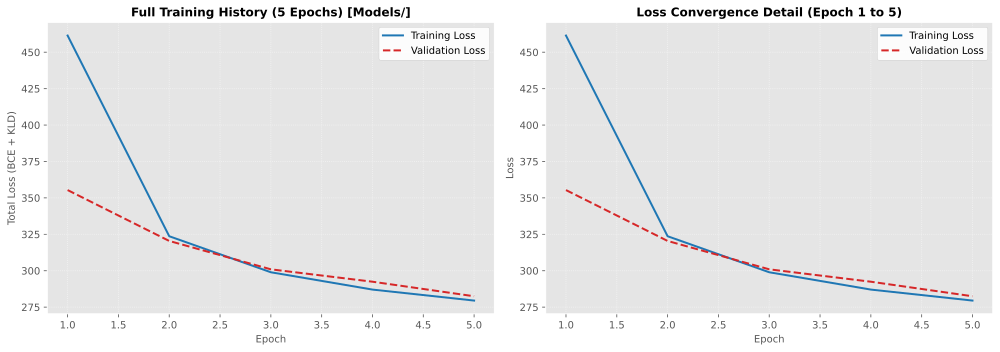

In [16]:
# Load training and validation loss histories
loaded_train_losses = None
loaded_val_losses = None

# Priority 1: Presaved loss histories
if os.path.exists('Presaved_Models/training_losses.txt') and os.path.exists('Presaved_Models/validation_losses.txt'):
    loaded_train_losses = np.loadtxt('Presaved_Models/training_losses.txt')
    loaded_val_losses = np.loadtxt('Presaved_Models/validation_losses.txt')
    loss_source = "Presaved_Models/"
# Priority 2: Newly trained loss histories from disk
elif os.path.exists('Models/training_losses.txt') and os.path.exists('Models/validation_losses.txt'):
    loaded_train_losses = np.loadtxt('Models/training_losses.txt')
    loaded_val_losses = np.loadtxt('Models/validation_losses.txt')
    loss_source = "Models/"
# Priority 3: In-memory loss tracking lists
elif 'train_losses' in globals() and len(train_losses) > 0 and 'val_losses' in globals() and len(val_losses) > 0:
    loaded_train_losses = np.array(train_losses)
    loaded_val_losses = np.array(val_losses)
    loss_source = "Active Session (Memory)"

if loaded_train_losses is not None and len(loaded_train_losses) > 0:
    total_epochs = len(loaded_train_losses)
    epochs_range = range(1, total_epochs + 1)

    # Create side-by-side loss visualizations
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Full training history
    axes[0].plot(epochs_range, loaded_train_losses, label='Training Loss', color='#1f77b4', linewidth=2)
    axes[0].plot(epochs_range, loaded_val_losses, label='Validation Loss', color='#d62728', linewidth=2, linestyle='--')
    axes[0].set_title(f'Full Training History ({total_epochs} Epochs) [{loss_source}]', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('Total Loss (BCE + KLD)', fontsize=10)
    axes[0].legend(frameon=True, facecolor='white', framealpha=0.9)
    axes[0].grid(True, linestyle=':', alpha=0.6)

    # Plot 2: Convergence / Detail view
    start_epoch = min(5, total_epochs) if total_epochs > 5 else 1
    axes[1].plot(range(start_epoch, total_epochs + 1), loaded_train_losses[start_epoch - 1:], label='Training Loss', color='#1f77b4', linewidth=2)
    axes[1].plot(range(start_epoch, total_epochs + 1), loaded_val_losses[start_epoch - 1:], label='Validation Loss', color='#d62728', linewidth=2, linestyle='--')
    axes[1].set_title(f'Loss Convergence Detail (Epoch {start_epoch} to {total_epochs})', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('Loss', fontsize=10)
    axes[1].legend(frameon=True, facecolor='white', framealpha=0.9)
    axes[1].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print('No loss records found in Presaved_Models/, Models/, or active session.')
    print('Execute Task 6.3 to train the model and generate loss curves.')


<a id="73-generating-characters"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">7.3 Generating New Characters from Random Latent Noise</span>


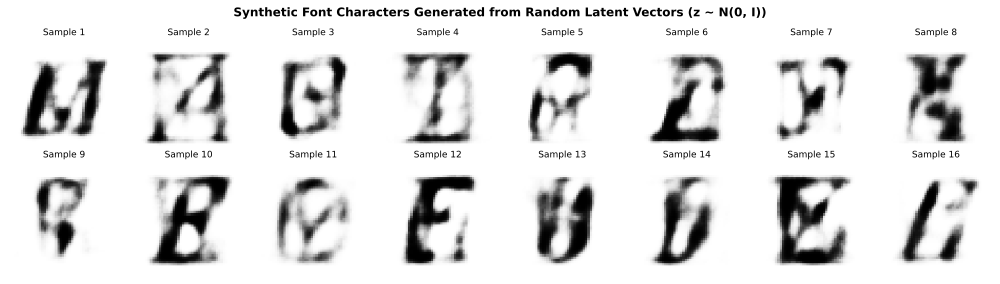

Successfully generated 16 synthetic font characters using weights from: 'Models/vae_latest.model'.


In [17]:
# Generate 16 novel font characters by sampling purely random Gaussian latent vectors
has_weights = ('loaded_checkpoint' in globals() and loaded_checkpoint is not None) or os.path.exists('Models/vae_latest.model') or os.path.exists('Presaved_Models/epoch_950.model')

with torch.no_grad():
    torch.manual_seed(42)
    
    # Sample random latent vectors z from standard normal distribution N(0, I)
    random_latent_vectors = torch.randn(16, latent_dim).to(device)
    
    # Pass through decoder to synthesize 50x50 images
    generated_images = model.decode(random_latent_vectors).view(16, image_size, image_size).cpu().numpy()

# Display the generated characters in a clean 2x8 subplot grid
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i], cmap='gray')
    ax.axis('off')
    ax.set_title(f'Sample {i+1}', fontsize=9)

plt.suptitle('Synthetic Font Characters Generated from Random Latent Vectors (z ~ N(0, I))', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

if not has_weights:
    print('\n' + '='*70)
    print('WARNING: No trained model weights loaded!')
    print('The images above are random noise from untrained weights.')
    print('To see meaningful results, either:')
    print('  1. Run the training section (Task 6.3) with the Font dataset')
    print('  2. Download pre-trained weights from the Google Drive link')
    print('='*70)
else:
    source_desc = loaded_checkpoint if ('loaded_checkpoint' in globals() and loaded_checkpoint) else 'Trained weights in Models/'
    print(f"Successfully generated 16 synthetic font characters using weights from: '{source_desc}'.")


<a id="74-latent-interpolation"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">7.4 Latent Space Interpolation (Morphing)</span>


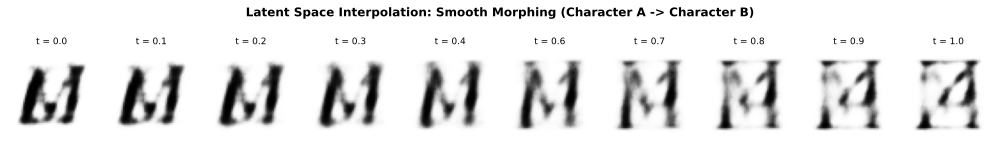

In [18]:
# Demonstrate latent space continuity: smooth interpolation between two characters
# NOTE: This requires a trained model. With untrained weights, output will be random noise.
with torch.no_grad():
    torch.manual_seed(42)
    
    # Pick two random endpoints in the 32-dimensional latent space
    z_start = torch.randn(1, latent_dim).to(device)
    z_end = torch.randn(1, latent_dim).to(device)
    
    # Generate 10 evenly spaced interpolation steps between z_start and z_end
    alphas = torch.linspace(0.0, 1.0, 10).to(device)
    interpolated_z = torch.cat([(1.0 - a) * z_start + a * z_end for a in alphas], dim=0)
    
    # Decode the path to produce smoothly morphing images
    morphing_images = model.decode(interpolated_z).view(10, 50, 50).cpu().numpy()

# Plot the smooth transition along the interpolation path
fig, axes = plt.subplots(1, 10, figsize=(14, 2.2))
for i, ax in enumerate(axes):
    ax.imshow(morphing_images[i], cmap='gray')
    ax.axis('off')
    ax.set_title(f't = {alphas[i].item():.1f}', fontsize=9)

plt.suptitle('Latent Space Interpolation: Smooth Morphing (Character A -> Character B)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


<a id="75-reconstructions"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">7.5 Validation Set Reconstruction: Input vs. VAE Output</span>


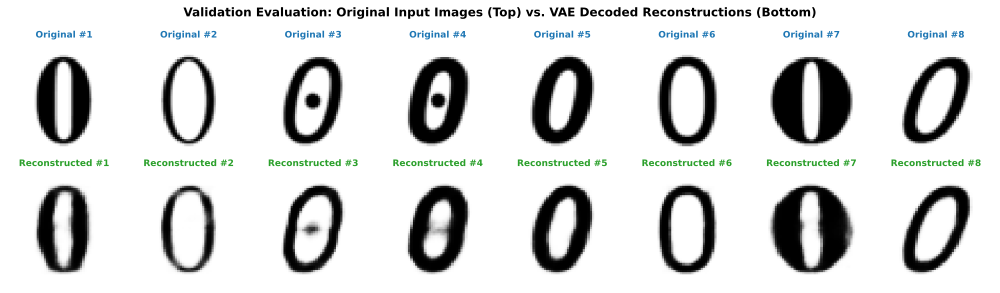

Compression Ratio: 2500 pixels -> 32 latent dimensions (~78x compression, 98.7% reduction)


In [19]:
# Live Reconstruction Comparison: Original Inputs vs. VAE Reconstructions
if val_loader is not None and len(val_loader) > 0:
    model.eval()
    with torch.no_grad():
        # Fetch a batch of real validation character images
        val_batch, _ = next(iter(val_loader))
        val_batch = val_batch.to(device)
        
        # Compress to 32-D latent space and reconstruct
        recon_batch, mu, logvar = model(val_batch)
        
        # Display 8 pairs: Original (Top row) vs. Reconstructed (Bottom row)
        n_display = 8
        fig, axes = plt.subplots(2, n_display, figsize=(14, 4.2))
        
        for i in range(n_display):
            # Original character image
            orig = val_batch[i].cpu().squeeze().numpy()
            axes[0, i].imshow(orig, cmap='gray')
            axes[0, i].axis('off')
            axes[0, i].set_title(f'Original #{i+1}', fontsize=9, fontweight='bold', color='#1f77b4')
            
            # VAE reconstructed character image (from 32 latent dimensions)
            recon = recon_batch[i].view(image_size, image_size).cpu().numpy()
            axes[1, i].imshow(recon, cmap='gray')
            axes[1, i].axis('off')
            axes[1, i].set_title(f'Reconstructed #{i+1}', fontsize=9, fontweight='bold', color='#2ca02c')
        
        plt.suptitle('Validation Evaluation: Original Input Images (Top) vs. VAE Decoded Reconstructions (Bottom)', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        print(f'Compression Ratio: 2500 pixels -> 32 latent dimensions (~78x compression, 98.7% reduction)')
elif os.path.exists('Results/reconstruction_1.png') or os.path.exists('Presaved_Results/reconstruction_950.png'):
    from IPython.display import Image, display
    img_path = 'Results/reconstruction_1.png' if os.path.exists('Results/reconstruction_1.png') else 'Presaved_Results/reconstruction_950.png'
    display(Image(filename=img_path))
else:
    print('Validation loader or saved reconstruction images not available.')
